# Empirical Validation of Theory

---

## Imports

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

from networks.BP_network import BP_network
from networks.EWC_network import EWC_network
from networks.EFC_network import EFC_network
from networks.EHC_network import EHC_network
from src.dataloaders import ClassILMNIST2Task
from src.utils import dotdict

from tqdm import tqdm
import os
from sklearn.decomposition import PCA
import pickle

## Config

In [24]:
config = {
    "lr": 1e-4,
    "batch_size": 256,
    "epochs": 20,
    "mode": "di",  # or "di"
    "num_workers": 0,
    "loss_fn": "ce", # "mse"
    "optimizer": "Adam",
    "scheduler": "CosineAnnealingLR",
    "device": "cpu" if torch.cuda.is_available() else "cpu",
    "output_dir": "./outputs",
    "seed": 0,
    "target_lr": 1e-2, # needs to be < time_constant_ratio
    "alpha_di": 0.0017,
    "alpha_I": 0.0017,
    "tau": 0.032,
    "dt_di": 0.02,
    "psi_lr": 0.1,
    "alpha_psi": 0.0,
    "time_constant_ratio": 0.2, # this param can be merged with dt_di
    "tmax_di": 500,
    "k_p": 2.0,
    "eps": 1e-4, # there is an interplay between dt_di and eps and between target_lr and eps
    "save": False,
    "importance_ewc": 4.0, # ewc params
    "beta_efc": 0.1, # efc params
    "flatten_imgs": True,
    "setting": "classIL2task", # domainIL, taskIL, classIL5task, classIL2task
    "peak": False, # saves the peak model based on cumulative accuracy and restores it after each task
    "layers": [784, 64, 64, 10],
    "num_tasks": 2,
    "classes_per_task": 5,
}

config = dotdict(config)
torch.set_default_device(config.device)
torch.manual_seed(config.seed)
np.random.seed(config.seed)

## Dataloaders – Class-IL 2-task Split-MNIST

In [25]:
dataloader = ClassILMNIST2Task(config)

train_loader_A, test_loader_A = dataloader.get_dataloaders(task_id=0)
train_loader_B, test_loader_B = dataloader.get_dataloaders(task_id=1)

print(f"Task A: {len(train_loader_A.dataset)} train, {len(test_loader_A.dataset)} test")
print(f"Task B: {len(train_loader_B.dataset)} train, {len(test_loader_B.dataset)} test_only")

Task A: 30596 train, 5139 test
Task B: 29404 train, 10000 test_only


## Train Task A on BP_network

In [26]:
def evaluate(net, loader, task_id, task_classes):
    net.eval()
    correct = total = 0.0
    total_loss = 0.0
    task_set = set(range(task_classes[0], task_classes[1] + 1))
    criterion = net.loss_fn  # CE or MSE

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(config.device), y.to(config.device)
            net.task_id = task_id
            out = net(x)
            true_labels = y.argmax(1)

            mask = torch.isin(true_labels, torch.tensor(list(task_set), device=config.device))
            if not mask.any():
                continue

            out = out[mask]
            y = y[mask]
            true_labels = true_labels[mask]

            start_idx = task_classes[0]
            pred_rel = out[:, start_idx:task_classes[1]+1].argmax(1)
            pred_abs = pred_rel + start_idx

            correct += (pred_abs == true_labels).sum().item()
            total += true_labels.size(0)
            total_loss += criterion(out[:, :task_classes[1]+1], y.argmax(1)).item() * true_labels.size(0)

    acc = correct / total if total else 0.0
    loss = total_loss / total if total else 0.0
    return acc, loss

In [27]:
bp_net_A = BP_network(config).to(config.device)
bp_net_A.task_id = 0
optimizer = optim.Adam(bp_net_A.parameters(), lr=config.lr)

bp_net_A.train()

for epoch in range(config.epochs):
    pbar = tqdm(total=len(train_loader_A), desc="BP (Task A)", unit="epoch", leave=True)
    for x, y in train_loader_A:
        x, y = x.to(config.device), y.to(config.device)

        optimizer.zero_grad()
        y_hat = bp_net_A(x)
        _ = bp_net_A.calculate_loss(y_hat, y.argmax(dim=1))
        bp_net_A.backward(y)          # BP-specific backward
        optimizer.step()

        pbar.update(1)

    # Train accuracy on Task A
    test_acc_A, _ = evaluate(bp_net_A, test_loader_A, task_id=0, task_classes=[0, 4])
    test_acc_B, _ = evaluate(bp_net_A, test_loader_B, task_id=1, task_classes=[5, 9])
    combined_test_acc, _ = evaluate(bp_net_A, test_loader_B, task_id=1, task_classes=[0, 9])  # all 10 classes are present

    # Update the progress-bar postfix
    pbar.set_postfix({
        "Test A" : f"{test_acc_A:.3f}",
        "Test B" : f"{test_acc_B:.3f}",
        "Comb"   : f"{combined_test_acc:.3f}"
    })

    pbar.close()

BP (Task A):   0%|          | 0/120 [00:00<?, ?epoch/s]

BP (Task A): 100%|██████████| 120/120 [00:00<00:00, 129.34epoch/s, Test A=0.986, Test B=0.271, Comb=0.507]


## Copy Weights to All Methods & Reset Optimizers

In [28]:
config.epochs=2
config.lr=1e-3

In [29]:
def copy_weights(src_net, dst_net):
    dst_net.load_state_dict(deepcopy(src_net.state_dict()))

# Create all networks
ewc_net = EWC_network(config).to(config.device)
efc_net = EFC_network(config).to(config.device)
bp_net = BP_network(config).to(config.device)
ehc_net = EHC_network(config).to(config.device)

# Set to train mode
ewc_net.train()
efc_net.train()
bp_net.train()
ehc_net.train()

nets = {
    'bp': bp_net,
    'ewc': ewc_net,
    'efc': efc_net,
    'ehc': ehc_net
}

# Reset task IDs
ewc_net.task_id = 0
efc_net.task_id = 0
bp_net.task_id = 0
ehc_net.task_id = 0

# Copy Task A weights
copy_weights(bp_net_A, ewc_net)
copy_weights(bp_net_A, efc_net)
copy_weights(bp_net_A, bp_net)
copy_weights(bp_net_A, ehc_net)

# Reset optimizers
optimizers = {
    'ewc': optim.Adam(ewc_net.parameters(), lr=config.lr),
    'efc': optim.Adam(efc_net.parameters(), lr=config.lr),
    'bp':  optim.Adam(bp_net.parameters(), lr=config.lr),
    'ehc': optim.Adam(ehc_net.parameters(), lr=config.lr),
}

print("Weights copied, optimizers reset.")

Weights copied, optimizers reset.


## Compute Fisher & Hessian

In [30]:
ewc_net.complete_task(train_loader_A)
efc_net.complete_task(train_loader_A)
bp_net.complete_task(train_loader_A)
ehc_net.complete_task(train_loader_A)

fisher_A = ewc_net._fisher
hessian_A = ehc_net._hessian

ewc_net.task_id = 1
efc_net.task_id = 1
bp_net.task_id = 1
ehc_net.task_id = 1

## Train and evaluate on Task B

In [31]:
weight_deltas = {name: [] for name in nets}  # List of dicts {param_name: delta_tensor} for first 5 batches
acc_logs = {name: {'acc_A': [], 'acc_B': [], 'combined': []} for name in nets}
loss_logs = {name: {'loss_A': [], 'loss_B': [], 'combined': []} for name in nets} 

for name, net in nets.items():
    opt = optimizers[name]
    net.train()
    batch_idx = 0
    old_params = {n: p.clone().detach() for n, p in net.named_parameters() if p.requires_grad}

    for epoch in range(config.epochs):
        pbar = tqdm(total=len(train_loader_B), desc=f"{name} (Task B)", unit="epoch", leave=True)
        for x, y in train_loader_B:
            x, y = x.to(config.device), y.to(config.device)

            opt.zero_grad()
            y_hat = net(x)
            _ = net.calculate_loss(y_hat, y.argmax(dim=1))
            net.backward(y)
            opt.step()

            pbar.update(1)
            batch_idx += 1

            if batch_idx % 10 == 0:
                (acc_A, loss_A)       = evaluate(net, test_loader_A, task_id=0, task_classes=[0, 4])
                (acc_B, loss_B)       = evaluate(net, test_loader_B, task_id=1, task_classes=[5, 9])
                (acc_comb, loss_comb) = evaluate(net, test_loader_B, task_id=1, task_classes=[0, 9])

                acc_logs[name]['acc_A'].append(acc_A)
                acc_logs[name]['acc_B'].append(acc_B)
                acc_logs[name]['combined'].append(acc_comb)

                loss_logs[name]['loss_A'].append(loss_A)
                loss_logs[name]['loss_B'].append(loss_B)
                loss_logs[name]['combined'].append(loss_comb)

                pbar.set_postfix({
                    'A': f'{acc_A:.3f}',
                    'B': f'{acc_B:.3f}',
                    'C': f'{acc_comb:.3f}',
                    'LA': f'{loss_A:.3f}',
                    'LB': f'{loss_B:.3f}',
                    'LC': f'{loss_comb:.3f}'
                })
                
                if batch_idx != 0:
                    delta = {n: p - old_params[n] for n, p in net.named_parameters() if p.requires_grad}
                    weight_deltas[name].append(delta)
                    old_params = {n: p.clone().detach() for n, p in net.named_parameters() if p.requires_grad}

        pbar.close()

ehc (Task B): 100%|██████████| 115/115 [02:23<00:00,  1.24s/epoch, A=0.600, B=0.961, C=0.467, LA=1.328, LB=0.125, LC=5.983]


## Save & Load

In [34]:
out_dir = config.output_dir if hasattr(config, "output_dir") else "./outputs"
os.makedirs(out_dir, exist_ok=True)

theta_0_flat = flatten_params(bp_net_A)

with open(os.path.join(out_dir, "theta_0_flat.pkl"), "wb") as f:
    # detach and move to cpu to ensure picklable tensors
    pickle.dump(theta_0_flat.detach().cpu(), f)

with open(os.path.join(out_dir, "weight_deltas.pkl"), "wb") as f:
    pickle.dump(weight_deltas, f)

with open(os.path.join(out_dir, "acc_logs.pkl"), "wb") as f:
    pickle.dump(acc_logs, f)

with open(os.path.join(out_dir, "loss_logs.pkl"), "wb") as f:
    pickle.dump(loss_logs, f)

print("Saved: bp_net_A_starting_state.pkl, theta_0_flat.pkl, weight_deltas.pkl, acc_logs.pkl, loss_logs.pkl")

Saved: bp_net_A_starting_state.pkl, theta_0_flat.pkl, weight_deltas.pkl, acc_logs.pkl, loss_logs.pkl


In [8]:
# Load previously saved artifacts (theta_0_flat.pkl, weight_deltas.pkl, acc_logs.pkl, loss_logs.pkl)
out_dir = config.output_dir if hasattr(config, "output_dir") else "./outputs"

def _safe_load(fname):
    path = os.path.join(out_dir, fname)
    if not os.path.exists(path):
        print(f"[load] missing: {path}")
        return None
    with open(path, "rb") as f:
        obj = pickle.load(f)
    print(f"[load] loaded: {path} (type={type(obj)})")
    return obj

# Load files
_loaded_theta = _safe_load("theta_0_flat.pkl")
_loaded_weight_deltas = _safe_load("weight_deltas.pkl")
_loaded_acc_logs = _safe_load("acc_logs.pkl")
_loaded_loss_logs = _safe_load("loss_logs.pkl")

# Assign into notebook variables (override only if loaded successfully)
if _loaded_weight_deltas is not None:
    weight_deltas = _loaded_weight_deltas

if _loaded_acc_logs is not None:
    acc_logs = _loaded_acc_logs

if _loaded_loss_logs is not None:
    loss_logs = _loaded_loss_logs

if _loaded_theta is not None:
    # ensure tensor on correct device
    if isinstance(_loaded_theta, torch.Tensor):
        theta_0_flat = _loaded_theta.to(config.device)
    else:
        theta_0_flat = torch.as_tensor(_loaded_theta, device=config.device, dtype=torch.float32)

# Print short summaries
print("\nSummary:")
if isinstance(weight_deltas, dict):
    for m, lst in weight_deltas.items():
        print(f" - weight_deltas[{m}]: {len(lst)} steps")
else:
    print(f" - weight_deltas: {type(weight_deltas)}")

print(f" - acc_logs keys: {list(acc_logs.keys()) if isinstance(acc_logs, dict) else type(acc_logs)}")
print(f" - loss_logs keys: {list(loss_logs.keys()) if isinstance(loss_logs, dict) else type(loss_logs)}")
print(f" - theta_0_flat: {theta_0_flat.shape if isinstance(theta_0_flat, torch.Tensor) else type(theta_0_flat)}")

[load] loaded: ./outputs/theta_0_flat.pkl (type=<class 'torch.Tensor'>)
[load] loaded: ./outputs/weight_deltas.pkl (type=<class 'dict'>)
[load] loaded: ./outputs/acc_logs.pkl (type=<class 'dict'>)
[load] loaded: ./outputs/loss_logs.pkl (type=<class 'dict'>)

Summary:
 - weight_deltas[bp]: 20 steps
 - weight_deltas[ewc]: 20 steps
 - weight_deltas[efc]: 20 steps
 - weight_deltas[ehc]: 20 steps
 - acc_logs keys: ['bp', 'ewc', 'efc', 'ehc']
 - loss_logs keys: ['bp', 'ewc', 'efc', 'ehc']
 - theta_0_flat: torch.Size([55050])


## (0) Performance metrics

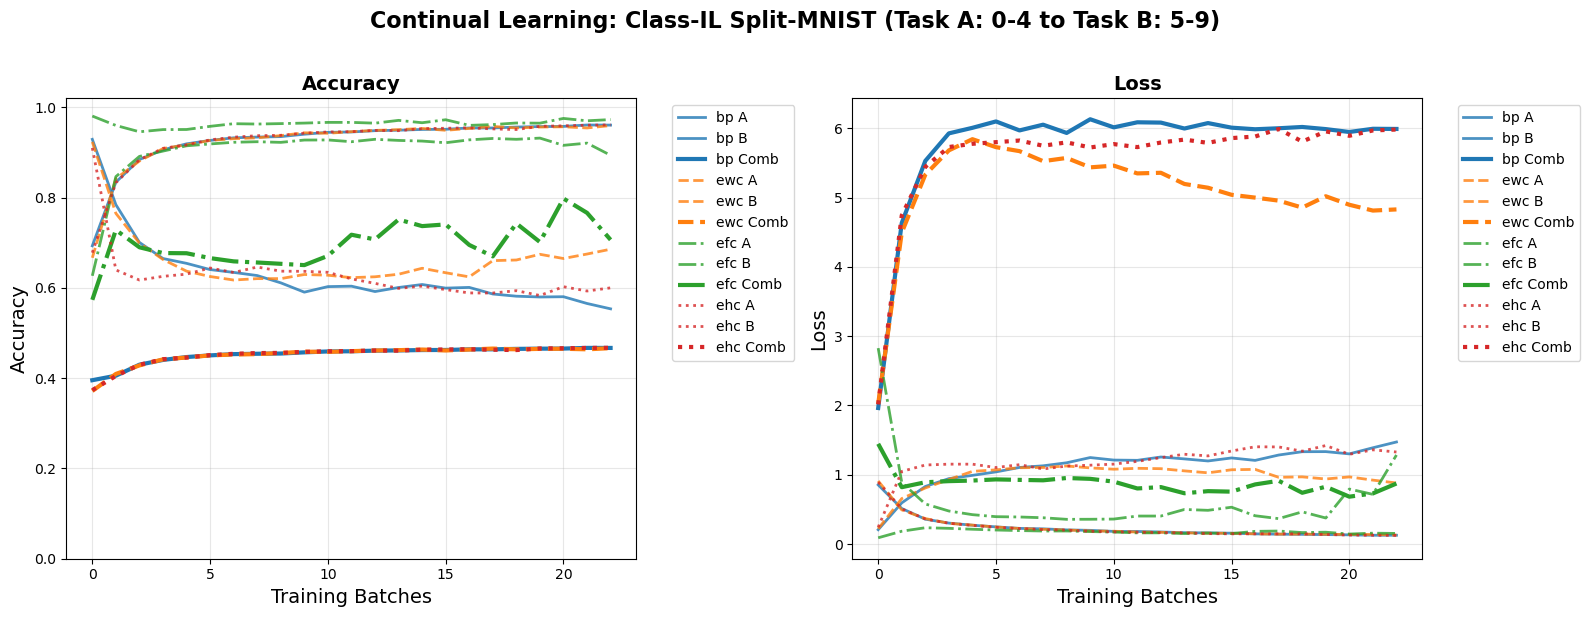


FINAL RESULTS (after Task B)
bp       | A: 0.554 (L: 1.473) | B: 0.961 (L: 0.127) | Comb: 0.467 (L: 5.991)
ewc      | A: 0.686 (L: 0.881) | B: 0.960 (L: 0.130) | Comb: 0.467 (L: 4.830)
efc      | A: 0.973 (L: 0.153) | B: 0.894 (L: 1.285) | Comb: 0.707 (L: 0.874)
ehc      | A: 0.600 (L: 1.328) | B: 0.961 (L: 0.125) | Comb: 0.467 (L: 5.983)


In [32]:
fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

colors = {'bp': 'tab:blue', 'ewc': 'tab:orange', 'efc': 'tab:green', 'ehc': 'tab:red'}
linestyles = {'bp': '-', 'ewc': '--', 'efc': '-.', 'ehc': ':'}

for name in nets.keys():
    x = np.arange(len(acc_logs[name]['acc_A']))

    # --- Accuracy subplot ---
    ax_acc.plot(x, acc_logs[name]['acc_A'], label=f'{name} A', color=colors[name], linestyle=linestyles[name], lw=2, alpha=0.8)
    ax_acc.plot(x, acc_logs[name]['acc_B'], label=f'{name} B', color=colors[name], linestyle=linestyles[name], lw=2, alpha=0.8)
    ax_acc.plot(x, acc_logs[name]['combined'], label=f'{name} Comb', color=colors[name], linestyle=linestyles[name], lw=3)

    # --- Loss subplot ---
    ax_loss.plot(x, loss_logs[name]['loss_A'], label=f'{name} A', color=colors[name], linestyle=linestyles[name], lw=2, alpha=0.8)
    ax_loss.plot(x, loss_logs[name]['loss_B'], label=f'{name} B', color=colors[name], linestyle=linestyles[name], lw=2, alpha=0.8)
    ax_loss.plot(x, loss_logs[name]['combined'], label=f'{name} Comb', color=colors[name], linestyle=linestyles[name], lw=3)

# --- Formatting ---
ax_acc.set_xlabel('Training Batches', fontsize=14)
ax_acc.set_ylabel('Accuracy', fontsize=14)
ax_acc.set_title('Accuracy', fontsize=14, fontweight='bold')
ax_acc.set_ylim(0, 1.02)
ax_acc.grid(True, alpha=0.3)
ax_acc.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

ax_loss.set_xlabel('Training Batches', fontsize=14)
ax_loss.set_ylabel('Loss', fontsize=14)
ax_loss.set_title('Loss', fontsize=14, fontweight='bold')
ax_loss.grid(True, alpha=0.3)
ax_loss.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

fig.suptitle('Continual Learning: Class-IL Split-MNIST (Task A: 0-4 to Task B: 5-9)', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# --- Final metrics ---
print("\n" + "="*70)
print("FINAL RESULTS (after Task B)")
print("="*70)
for name in nets.keys():
    print(f"{name:8s} | "
          f"A: {acc_logs[name]['acc_A'][-1]:.3f} (L: {loss_logs[name]['loss_A'][-1]:.3f}) | "
          f"B: {acc_logs[name]['acc_B'][-1]:.3f} (L: {loss_logs[name]['loss_B'][-1]:.3f}) | "
          f"Comb: {acc_logs[name]['combined'][-1]:.3f} (L: {loss_logs[name]['combined'][-1]:.3f})")
print("="*70)

## (1) Task A Loss Contour Plot

In [33]:
# Flatten all trainable params
def flatten_params(model):
    return torch.cat([p.flatten() for p in model.parameters() if p.requires_grad])

# Unflatten vector back to model
def unflatten_params(flat_vec, model):
    offset = 0
    for p in model.parameters():
        if p.requires_grad:
            numel = p.numel()
            p.data.copy_(flat_vec[offset:offset + numel].view(p.shape))
            offset += numel

# Evaluate Task A loss on full test set
def loss_A_at_params(model, params_flat, test_loader_A):
    orig_flat = flatten_params(model)
    unflatten_params(params_flat, model)
    model.eval()
    model.task_id = 0
    total_loss = 0.0
    total_samples = 0
    with torch.no_grad():
        for x, y in test_loader_A:
            x, y = x.to(model.device), y.to(model.device)
            out = model(x)
            loss = model.loss_fn(out, y.argmax(dim=1))
            total_loss += loss.item() * x.size(0)
            total_samples += x.size(0)
    unflatten_params(orig_flat, model)  # restore
    return total_loss / total_samples if total_samples > 0 else 0.0

In [35]:
num_steps = 20
theta_0_flat = flatten_params(bp_net_A)  # center (0,0)

# EHC end point (y-axis: optimal second-order)
ehc_end_flat = theta_0_flat.clone()
for step in range(num_steps):
    delta_dict = weight_deltas['efc'][step]
    delta_flat = torch.cat([d.flatten() for d in delta_dict.values()])
    ehc_end_flat += delta_flat

# BP_B end point (x-axis: worst first-order)
bp_end_flat = theta_0_flat.clone()
for step in range(num_steps):
    delta_dict = weight_deltas['bp'][step]
    delta_flat = torch.cat([d.flatten() for d in delta_dict.values()])
    bp_end_flat += delta_flat

# Directions (normalized)
d1 = ehc_end_flat - theta_0_flat
d2 = bp_end_flat - theta_0_flat

len_d1 = d1.norm()
len_d2 = d2.norm()

d1_norm = d1 / len_d1
d2_norm = d2 / len_d2

# proj = (d2_norm @ d1_norm).item()
# d2_orth = d2_norm - proj * d1_norm
# len_d2_orth = d2_orth.norm()
# d2_orth_norm = d2_orth / len_d2_orth

In [25]:
grid_size = 40
grid_range = 1.2  # [0, 1.2] in scaled units

# Create meshgrid
alpha, beta = np.meshgrid(
    np.linspace(-grid_range, grid_range, grid_size),
    np.linspace(-grid_range, grid_range, grid_size)
)

losses_A = np.zeros((grid_size, grid_size))

print("Evaluating Task A loss on [-1.2,1.2]x[-1.2,1.2] parameter grid...")
pbar = tqdm(total=grid_size**2, desc="Grid Eval", unit="point")

for i in range(grid_size):
    for j in range(grid_size):
        delta = alpha[i,j] * len_d2 * d2_norm + beta[i,j] * len_d1 * d1_norm
        interp_params = theta_0_flat + delta
        losses_A[i, j] = loss_A_at_params(bp_net_A, interp_params, test_loader_A)
        pbar.update(1)

pbar.close()
print("Grid evaluation complete.")

Evaluating Task A loss on [-1.2,1.2]x[-1.2,1.2] parameter grid...


Grid Eval: 100%|██████████| 1600/1600 [02:01<00:00, 13.14point/s]

Grid evaluation complete.


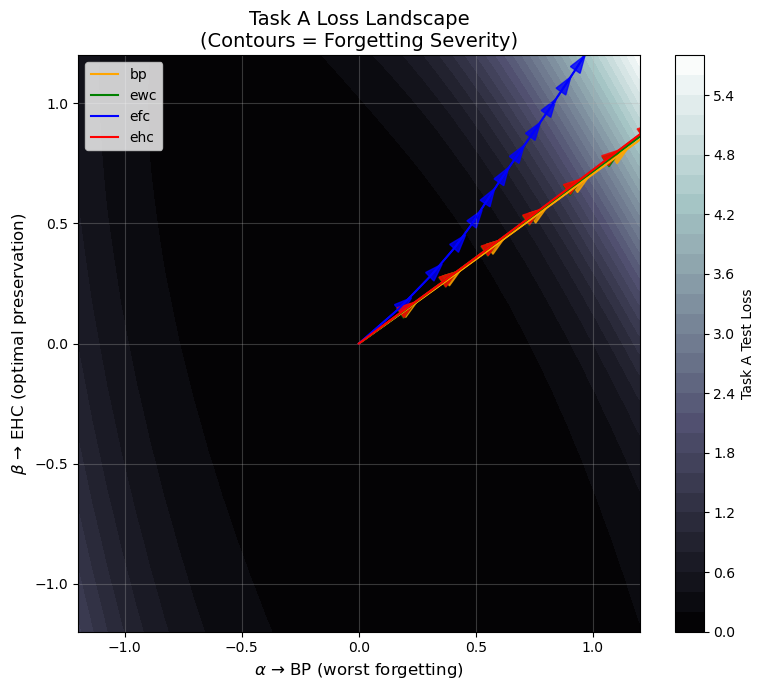

In [27]:
plt.figure(figsize=(8, 7))
plt.contourf(alpha, beta, losses_A, levels=30, cmap='bone')
plt.colorbar(label='Task A Test Loss')

# Method colors
colors = {'bp': 'orange', 'ewc': 'green', 'efc': 'blue', 'ehc': 'red'}
methods = ['bp', 'ewc', 'efc', 'ehc']

# Plot each method's trajectory (cumulative over 5 steps)
for method in methods:
    cum_flat = theta_0_flat.clone()
    traj_x, traj_y = [0.0], [0.0]
    for step in range(20):
        delta_flat = torch.cat([d.flatten() for d in weight_deltas[method][step].values()])
        cum_flat += delta_flat

        proj_x = float(((cum_flat - theta_0_flat) @ d2_norm).item())
        proj_y = float(((cum_flat - theta_0_flat) @ d1_norm).item())

        traj_x.append(proj_x)
        traj_y.append(proj_y)

    traj_x = np.array(traj_x, dtype=np.float64)
    traj_y = np.array(traj_y, dtype=np.float64)

    plt.plot(traj_x, traj_y, '-', color=colors[method], label=method)
    for k in range(1, len(traj_x)):
        plt.arrow(traj_x[k-1], traj_y[k-1],
                  traj_x[k] - traj_x[k-1], traj_y[k] - traj_y[k-1],
                  color=colors[method], head_width=0.05, alpha=0.8)

plt.xlim(-grid_range, grid_range)
plt.ylim(-grid_range, grid_range)
plt.xlabel(r'$\alpha$ → BP (worst forgetting)', fontsize=12)
plt.ylabel(r'$\beta$ → EHC (optimal preservation)', fontsize=12)
plt.title('Task A Loss Landscape\n(Contours = Forgetting Severity)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## (1a) PCA Contour plot

In [40]:
# Flatten all trainable params
def flatten_params(model):
    return torch.cat([p.flatten() for p in model.parameters() if p.requires_grad])

# Unflatten vector back to model
def unflatten_params(flat_vec, model):
    offset = 0
    for p in model.parameters():
        if p.requires_grad:
            numel = p.numel()
            p.data.copy_(flat_vec[offset:offset + numel].view(p.shape))
            offset += numel

def evaluate(net, loader, task_id, task_classes):
    net.eval()
    correct = total = 0.0
    total_loss = 0.0
    task_set = set(range(task_classes[0], task_classes[1] + 1))
    criterion = net.loss_fn  # CE or MSE

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(config.device), y.to(config.device)
            net.task_id = task_id
            out = net(x)
            true_labels = y.argmax(1)

            mask = torch.isin(true_labels, torch.tensor(list(task_set), device=config.device))
            if not mask.any():
                continue

            out = out[mask]
            y = y[mask]
            true_labels = true_labels[mask]

            start_idx = task_classes[0]
            pred_rel = out[:, start_idx:task_classes[1]+1].argmax(1)
            pred_abs = pred_rel + start_idx

            correct += (pred_abs == true_labels).sum().item()
            total += true_labels.size(0)
            total_loss += criterion(out[:, :task_classes[1]+1], y.argmax(1)).item() * true_labels.size(0)

    acc = correct / total if total else 0.0
    loss = total_loss / total if total else 0.0
    return acc, loss

# Evaluate losses using evaluate()
def loss_A_at_params(model, params_flat, test_loader_A):
    orig_flat = flatten_params(model)
    unflatten_params(params_flat, model)
    _, loss = evaluate(model, test_loader_A, task_id=0, task_classes=[0, 4])
    unflatten_params(orig_flat, model)
    return loss

def loss_B_at_params(model, params_flat, test_loader_B):
    orig_flat = flatten_params(model)
    unflatten_params(params_flat, model)
    _, loss = evaluate(model, test_loader_B, task_id=1, task_classes=[5, 9])
    unflatten_params(orig_flat, model)
    return loss

def loss_combined_at_params(model, params_flat, test_loader_B):
    orig_flat = flatten_params(model)
    unflatten_params(params_flat, model)
    _, loss = evaluate(model, test_loader_B, task_id=1, task_classes=[0, 9])
    unflatten_params(orig_flat, model)
    return loss

In [41]:
num_steps = 20

# Collect all deltas into a matrix for PCA
methods = ['bp', 'ewc', 'efc', 'ehc']
delta_matrix = []
for method in methods:
    for step in range(num_steps):
        delta_dict = weight_deltas[method][step]
        delta_flat = torch.cat([d.flatten() for d in delta_dict.values()])
        delta_matrix.append(delta_flat.cpu().detach().numpy())

delta_matrix = np.array(delta_matrix).T  # Shape: (p, M * S)

# Perform PCA
pca = PCA(n_components=2)
pca.fit(delta_matrix.T)  # Fit on (M*S, p)
pc1 = torch.from_numpy(pca.components_[0]).to(theta_0_flat.device).float()
pc2 = torch.from_numpy(pca.components_[1]).to(theta_0_flat.device).float()

len_pc1 = pc1.norm()
len_pc2 = pc2.norm()
pc1_norm = pc1 / len_pc1
pc2_norm = pc2 / len_pc2

In [51]:
grid_size = 20
grid_range = 10

alpha, beta = np.meshgrid(
    np.linspace(-0.5, 1.5, grid_size),
    np.linspace(0, 3, grid_size)
)

losses_A = np.zeros((grid_size, grid_size))
losses_B = np.zeros((grid_size, grid_size))
losses_combined = np.zeros((grid_size, grid_size))

print("Evaluating losses on PCA-projected grid")
pbar = tqdm(total=grid_size**2, desc="Grid Eval", unit="point")

for i in range(grid_size):
    for j in range(grid_size):
        delta = alpha[i,j] * len_pc2 * pc2_norm + beta[i,j] * len_pc1 * pc1_norm
        interp_params = theta_0_flat + delta

        losses_A[i, j] = loss_A_at_params(bp_net_A, interp_params, test_loader_A)
        losses_B[i, j] = loss_B_at_params(bp_net_A, interp_params, test_loader_B)
        losses_combined[i, j] = loss_combined_at_params(bp_net_A, interp_params, test_loader_B)
        pbar.update(1)

pbar.close()
print(f"Grid evaluation complete. Variance explained: {pca.explained_variance_ratio_}")

Evaluating losses on PCA-projected grid


Grid Eval: 100%|██████████| 400/400 [02:29<00:00,  2.67point/s]

Grid evaluation complete. Variance explained: [0.67201084 0.07130387]


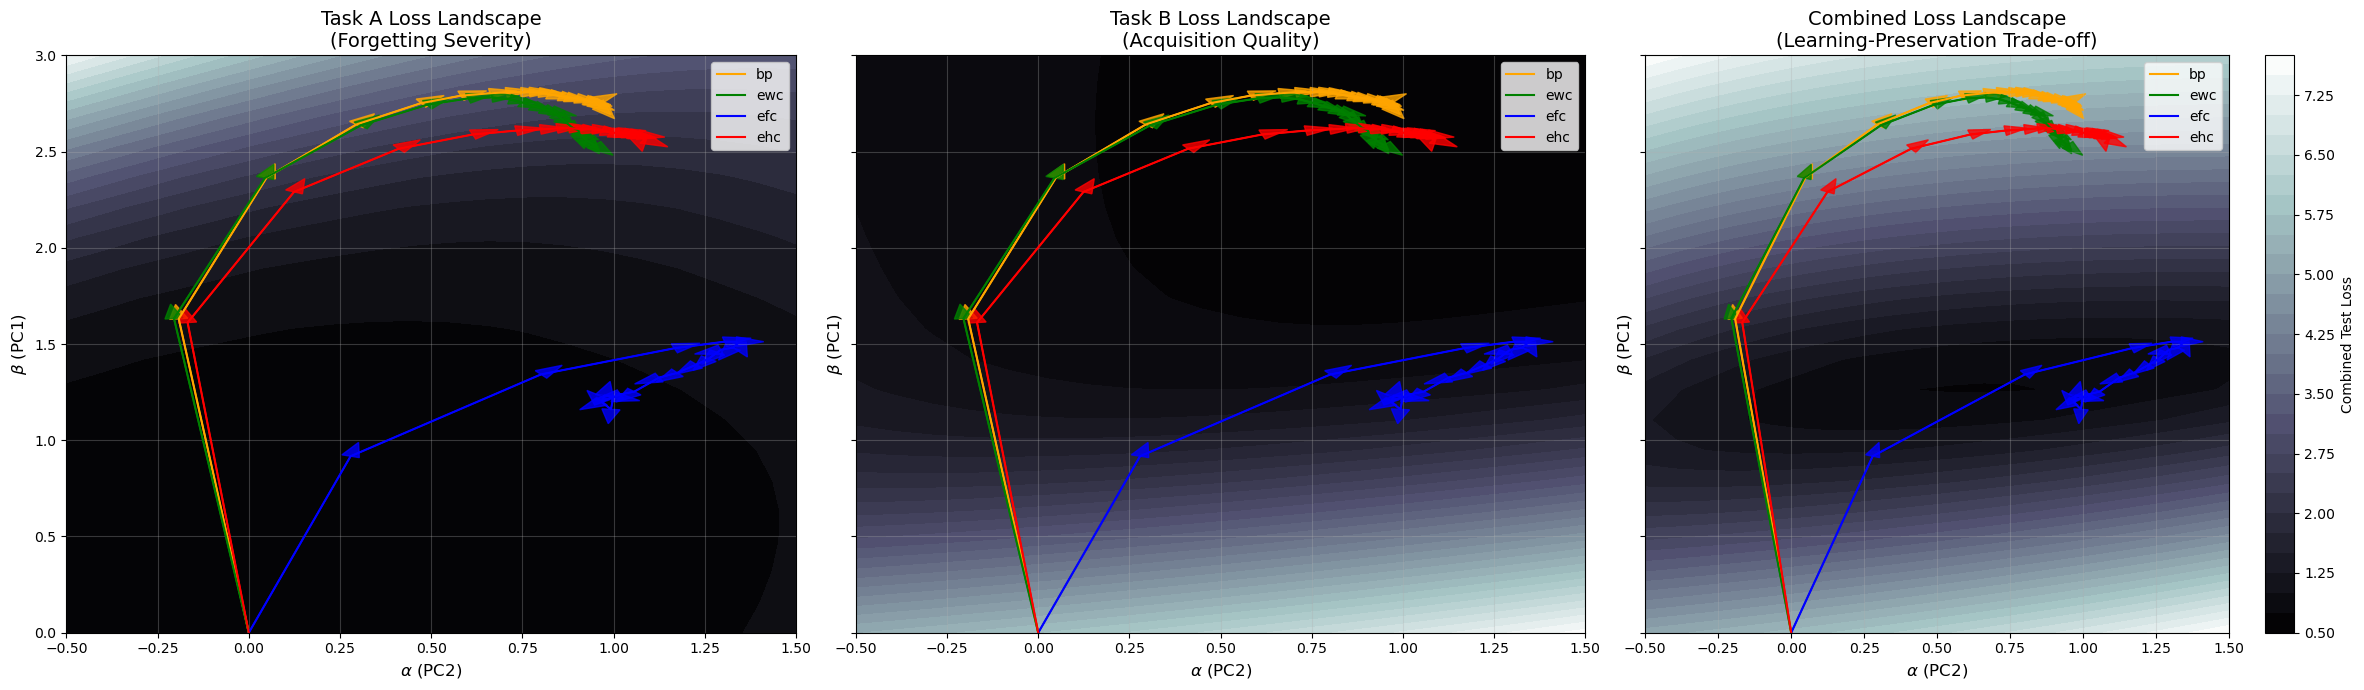

In [52]:
# Plotting
fig, axs = plt.subplots(1, 3, figsize=(24, 7), sharey=True)

# Method colors
colors = {'bp': 'orange', 'ewc': 'green', 'efc': 'blue', 'ehc': 'red'}

# Function to plot trajectories on a given ax
def plot_trajectories(ax):
    for method in methods:
        cum_flat = theta_0_flat.clone()
        traj_x, traj_y = [0.0], [0.0]
        for step in range(num_steps):
            delta_flat = torch.cat([d.flatten() for d in weight_deltas[method][step].values()])
            cum_flat += delta_flat

            proj_x = float(((cum_flat - theta_0_flat) @ pc2_norm).item())
            proj_y = float(((cum_flat - theta_0_flat) @ pc1_norm).item())

            traj_x.append(proj_x)
            traj_y.append(proj_y)

        traj_x = np.array(traj_x, dtype=np.float64)
        traj_y = np.array(traj_y, dtype=np.float64)

        ax.plot(traj_x, traj_y, '-', color=colors[method], label=method)
        for k in range(1, len(traj_x)):
            ax.arrow(traj_x[k-1], traj_y[k-1],
                     traj_x[k] - traj_x[k-1], traj_y[k] - traj_y[k-1],
                     color=colors[method], head_width=0.05, alpha=0.8)

# Plot 1: Task A
axs[0].contourf(alpha, beta, losses_A, levels=30, cmap='bone')
axs[0].set_title('Task A Loss Landscape\n(Forgetting Severity)', fontsize=14)
plot_trajectories(axs[0])

# Plot 2: Task B
axs[1].contourf(alpha, beta, losses_B, levels=30, cmap='bone')
axs[1].set_title('Task B Loss Landscape\n(Acquisition Quality)', fontsize=14)
plot_trajectories(axs[1])

# Plot 3: Combined
c = axs[2].contourf(alpha, beta, losses_combined, levels=30, cmap='bone')
axs[2].set_title('Combined Loss Landscape\n(Learning-Preservation Trade-off)', fontsize=14)
plot_trajectories(axs[2])
fig.colorbar(c, ax=axs[2], label='Combined Test Loss')

for ax in axs:
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(0, 3)
    ax.set_xlabel(r'$\alpha$ (PC2)', fontsize=12)
    ax.set_ylabel(r'$\beta$ (PC1)', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
losses_combined.shape

(30, 30)

## (2) t-SNE Weight Update Projections

In [ ]:
# from sklearn.manifold import TSNE  # Or PCA

# # Collect over N=32 batch samples: lists of delta_W_star, delta_W_BP, delta_W_tilde_F, delta_W_diag_F
# # Flatten each to 1D tensors, then numpy arrays
# anchors = np.vstack([np.array(flatten_delta_W_star), np.array(flatten_delta_W_BP)])  # (2N x p)

# tsne = TSNE(n_components=2, perplexity=10)  # Or PCA
# tsne.fit(anchors)  # Fit only on Hessian + BP

# proj_star = tsne.transform(np.array(flatten_delta_W_star))
# proj_BP = tsne.transform(np.array(flatten_delta_W_BP))
# proj_tilde_F = tsne.transform(np.array(flatten_delta_W_tilde_F))
# proj_diag_F = tsne.transform(np.array(flatten_delta_W_diag_F))

# plt.scatter(proj_star[:,0], proj_star[:,1], color='red', label=r'Hessian $\Delta W^*$')
# plt.scatter(proj_BP[:,0], proj_BP[:,1], color='orange', label='BP')
# plt.scatter(proj_tilde_F[:,0], proj_tilde_F[:,1], color='blue', label=r'EFC $\tilde{F}_A$')
# plt.scatter(proj_diag_F[:,0], proj_diag_F[:,1], color='green', label=r'Diag $F_A^D$')
# # Connect pairs: for i in range(N): plt.plot([proj_star[i,0], proj_tilde_F[i,0]], [proj_star[i,1], proj_tilde_F[i,1]], 'b--')
# plt.legend(); plt.title('Projected Updates (Anchored to Hessian & BP)'); plt.show()

## (3) Eigenvalue Spectrum

Todo: Extract \tilde{F}_A from dynamics

In [ ]:
# This comparison visualizes matrix similarity via eigenvalue distributions (curvature scales) and quadratic forms (anisotropic shapes in subspaces). Compute eigenvalues for each matrix ($H_A$, $\tilde{F}_A$, $F_A^D$; note $F_A^D$ is diagonal, so its eigenvalues are its entries). Overlay spectra as line plots (sorted eigenvalues) to show overlap in magnitude/distribution—close curves mean similar curvatures. For deeper visual comparison, overlay 2D contours of quadratic approximations $\frac{1}{2} \delta^\top M \delta$ (where $M$ is each matrix) in a shared subspace (e.g., top-2 eigenvectors of $H_A$). This shows how each matrix's "bowl" shape aligns, with overlap as similar ellipse orientations/scales (validating $\tilde{F}_A \approx H_A > F_A^D$).
# Explicit Computation and Visualization:

# Eigenvalue Spectra: Compute sorted eigenvalues; plot as overlapping curves (x: eigenvalue index, y: value). Use log-scale if spectra span orders of magnitude.
# Quadratic Form Contours: Project into subspace spanned by top-2 eigenvectors $P$ of $H_A$ (columns of $P \in \mathbb{R}^{p \times 2}$). For grid $\delta = [\alpha, \beta]^\top$, compute $\frac{1}{2} (P \delta)^\top M (P \delta)$ for each $M$; contour-plot overlays.
# Tie to CL: Evaluate on $L_{A\&B}$ perturbations to link to forgetting.